In [4]:
# Build H_B, H_P and the linear path H(s)

import qiskit 
from qiskit.quantum_info import SparsePauliOp


hx, J, hz = 1.0, 1.0 , 0.25
HB = SparsePauliOp.from_list([("IX", -hx), ("XI", -hx)])
HP = SparsePauliOp.from_list([("ZZ", -J), ("IZ", -hz), ("ZI", -hz)])

def H_of_s(s:float) -> SparsePauliOp:
    return ((1.0-s)*HB + s*HP).simplify()




In [46]:
import numpy as np
from qiskit.quantum_info import Operator

ss = np.linspace(0,1, 1001)
gaps = []
e0, e1 = [], []
for s in ss: 
    H = (1.0 - s) * HB + s * HP

    ev = np.linalg.eigvalsh(Operator(H).data)
    e0.append(ev[0])
    e1.append(ev[1])
    gaps.append(ev[1] - ev[0])

i = int(np.argmin(gaps))

s_star, Delta_min = float(ss[i]), float(gaps[i])

print(s_star, Delta_min)

0.621 0.658861132790103


Text(0, 0.5, 'Delta(s)')

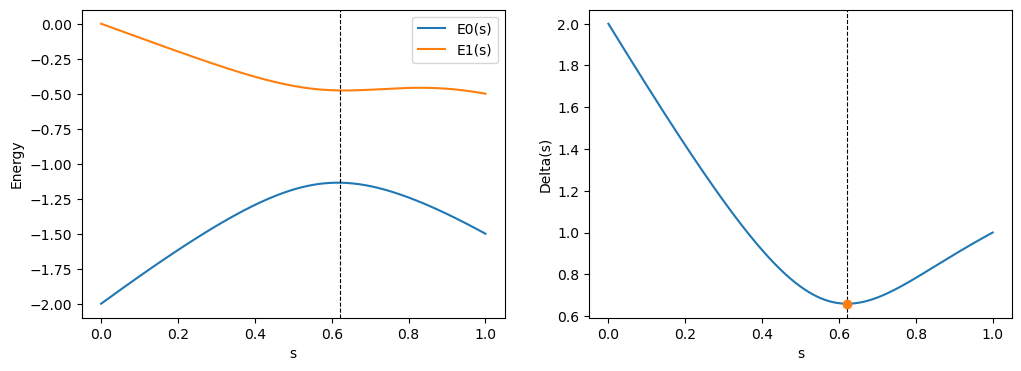

In [47]:
import  matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(ss, e0, label = 'E0(s)')
ax[0].plot(ss, e1, label = 'E1(s)')
ax[0].axvline(s_star, color = 'k', linestyle = '--', linewidth=0.8)
ax[0].set_xlabel('s')
ax[0].set_ylabel('Energy')
ax[0].legend()
ax[1].plot(ss, gaps)
ax[1].axvline(s_star,color = 'k', linestyle = '--',linewidth=0.8)
ax[1].plot([s_star], [Delta_min], marker = 'o')
ax[1].set_xlabel('s')
ax[1].set_ylabel('Delta(s)')



In [6]:
# Scan Delta(s)=E1(s)-E0(s) and locate the minimum (pedagogical excerpt)
import numpy as np
from qiskit.quantum_info import Operator, SparsePauliOp

hx, J, hz = 1.0, 1.0, 0.25
HB = SparsePauliOp.from_list([("IX", -hx), ("XI", -hx)])
HP = SparsePauliOp.from_list([("ZZ", -J), ("IZ", -hz), ("ZI", -hz)])

ss = np.linspace(0.0, 1.0, 2001)
gaps = []
for s in ss:
    H = (1.0 - s) * HB + s * HP
    e0, e1 = np.linalg.eigvalsh(Operator(H).data)[:2]
    gaps.append(e1 - e0)

i = int(np.argmin(gaps))
s_star, Delta_min = float(ss[i]), float(gaps[i])
print(s_star, Delta_min)

0.6215 0.6588609839027761


In [53]:
# Heuristic T from spectral norm of dH/ds and Delta_min
import numpy as np
from qiskit.quantum_info import Operator, SparsePauliOp

hx, J, hz = 1.0, 1.0, 0.25

eps = 1e-2

Delta_min = 0.65886098 # from previous calculation
HB = SparsePauliOp.from_list([("IX", -hx), ("XI", -hx)])
HP = SparsePauliOp.from_list([("ZZ", -J), ("IZ", -hz), ("ZI", -hz)])

norm = float(np.linalg.norm((Operator(HP) - Operator(HB)).data, ord=2))

H_heur = norm / (eps * Delta_min**2)

print(f"norm(dH/ds) = {norm:.4f}, T_heuristic = {H_heur:.4f}")

norm(dH/ds) = 2.3696, T_heuristic = 545.8708
